In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
import numpy as np
from sklearn.model_selection import train_test_split

1. Load and combine data

In [3]:
import glob
import os

DATA_DIR_A = "SetA"
DATA_DIR_B = "SetB"
DATA_DIR_C = "SetC"
DATA_DIR_D = "SetD"
DATA_DIR_E = "SetE"

LABEL_C1 = 0 #A
LABEL_C2 = 0 #B
LABEL_C3 = 0 #C
LABEL_C4 = 0 #D
LABEL_C5 = 1 #E


def load_dataset(folder_path, label):
    data = []
    labels = []

    for file in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file)

        # each file is 1 signal that is 4097 samples in Bonn dataset (23.6*Fs)
        signal = np.loadtxt(file_path)

        data.append(signal)
        labels.append(label)

    return np.array(data), np.array(labels)



X_A, Y_A = load_dataset(DATA_DIR_A, LABEL_C1)
X_B, Y_B = load_dataset(DATA_DIR_B, LABEL_C2)
X_C, Y_C = load_dataset(DATA_DIR_C, LABEL_C3)
X_D, Y_D = load_dataset(DATA_DIR_D, LABEL_C4)
X_E, Y_E = load_dataset(DATA_DIR_E, LABEL_C5)



X_AE = np.concatenate([X_A, X_E], axis=0)
Y_AE= np.concatenate([Y_A, Y_E], axis=0)


X_ABCDE = np.concatenate([X_A, X_B, X_C, X_D, X_E], axis=0)
Y_ABCDE= np.concatenate([Y_A, Y_B, Y_C, Y_D, Y_E], axis=0)


2. Train/Test Split

In [9]:
from sklearn.model_selection import train_test_split

X_AE_train, X_AE_test, Y_AE_train, Y_AE_test = train_test_split(
    X_AE, Y_AE,
    test_size=0.3,
    random_state=42,
    stratify=Y_AE
)


X_ABCDE_train, X_ABCDE_test, Y_ABCDE_train, Y_ABCDE_test = train_test_split(
    X_ABCDE, Y_ABCDE,
    test_size=0.3,
    random_state=42,
    stratify=Y_ABCDE
)

3. Create DataLoaders

In [10]:
# Add channel dimension: (samples, 4097) -> (samples, 4097, 1)
X_AE_train = X_AE_train.reshape(-1, 4097, 1)
X_AE_test = X_AE_test.reshape(-1, 4097, 1)


# Convert to PyTorch tensors and create DataLoaders
X_AE_train_tensor = torch.FloatTensor(X_AE_train).permute(0, 2, 1)
X_AE_test_tensor = torch.FloatTensor(X_AE_test).permute(0, 2, 1)
Y_AE_train_tensor = torch.FloatTensor(Y_AE_train).view(-1, 1)
Y_AE_test_tensor = torch.FloatTensor(Y_AE_test).view(-1, 1)

train_dataset_AE = TensorDataset(X_AE_train_tensor, Y_AE_train_tensor)
test_dataset_AE = TensorDataset(X_AE_test_tensor, Y_AE_test_tensor)

train_loader_AE = DataLoader(train_dataset_AE, batch_size=50, shuffle=True)
test_loader_AE = DataLoader(test_dataset_AE, batch_size=50, shuffle=False)
# ------------------------------------

X_ABCDE_train = X_ABCDE_train.reshape(-1, 4097, 1)
X_ABCDE_test = X_ABCDE_test.reshape(-1, 4097, 1)


X_ABCDE_train_tensor = torch.FloatTensor(X_ABCDE_train).permute(0, 2, 1)
X_ABCDE_test_tensor = torch.FloatTensor(X_ABCDE_test).permute(0, 2, 1)
Y_ABCDE_train_tensor = torch.FloatTensor(Y_ABCDE_train).view(-1, 1)
Y_ABCDE_test_tensor = torch.FloatTensor(Y_ABCDE_test).view(-1, 1)

train_dataset_ABCDE = TensorDataset(X_ABCDE_train_tensor, Y_ABCDE_train_tensor)
test_dataset_ABCDE = TensorDataset(X_ABCDE_test_tensor, Y_ABCDE_test_tensor)

train_loader_ABCDE = DataLoader(train_dataset_ABCDE, batch_size=50, shuffle=True)
test_loader_ABCDE = DataLoader(test_dataset_ABCDE, batch_size=50, shuffle=False)

4. Model architecture (CNN Model)

In [6]:
class BonnCNN (nn.Module):
    def __init__(self):
        super(BonnCNN, self).__init__()
        
        # More gradual filter increase
        self.conv1 = nn.Conv1d(1, 16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(16)
        self.pool1 = nn.MaxPool1d(2)
        
        self.conv2 = nn.Conv1d(16, 32, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(32)
        self.pool2 = nn.MaxPool1d(2)
        
        self.conv3 = nn.Conv1d(32, 64, kernel_size=7, padding=3)
        self.bn3 = nn.BatchNorm1d(64)
        self.pool3 = nn.MaxPool1d(2)
        
        self.conv4 = nn.Conv1d(64, 128, kernel_size=9, padding=4)
        self.bn4 = nn.BatchNorm1d(128)
        self.pool4 = nn.MaxPool1d(2)
        
        # Global pooling
        self.gap = nn.AdaptiveAvgPool1d(1)
        
        # classifier
        self.fc1 = nn.Linear(128, 64)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(64, 1)
        
    def forward(self, x):
        x = torch.relu(self.bn1(self.conv1(x)))
        x = self.pool1(x)
        
        x = torch.relu(self.bn2(self.conv2(x)))
        x = self.pool2(x)
        
        x = torch.relu(self.bn3(self.conv3(x)))
        x = self.pool3(x)
        
        x = torch.relu(self.bn4(self.conv4(x)))
        x = self.pool4(x)
        
        x = self.gap(x)  # Global average pooling
        x = x.view(x.size(0), -1)
        
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.sigmoid(self.fc2(x))
        
        return x

5. Create and train model

In [14]:
import matplotlib.pyplot as plt

model= BonnCNN()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
criterion = nn.BCELoss()

# Store losses
train_losses = []
train_accuracies = []

for epoch in range(150):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for X_batch, y_batch in train_loader_AE:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        predicted = (outputs > 0.5).float()
        correct += (predicted == y_batch).sum().item()
        total += y_batch.size(0)
    
    epoch_loss = running_loss / len(train_loader_AE)
    epoch_acc = 100 * correct / total
    
    # Store
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)
    
    print(f"Epoch [{epoch+1}/150] - Loss: {epoch_loss:.4f} - Accuracy: {epoch_acc:.2f}%")

Epoch [1/150] - Loss: 0.6498 - Accuracy: 53.57%
Epoch [2/150] - Loss: 0.5909 - Accuracy: 77.86%
Epoch [3/150] - Loss: 0.5532 - Accuracy: 85.71%
Epoch [4/150] - Loss: 0.5383 - Accuracy: 88.57%
Epoch [5/150] - Loss: 0.5042 - Accuracy: 89.29%
Epoch [6/150] - Loss: 0.5027 - Accuracy: 90.71%
Epoch [7/150] - Loss: 0.4795 - Accuracy: 90.00%
Epoch [8/150] - Loss: 0.4751 - Accuracy: 91.43%
Epoch [9/150] - Loss: 0.4558 - Accuracy: 90.71%
Epoch [10/150] - Loss: 0.4479 - Accuracy: 90.71%
Epoch [11/150] - Loss: 0.4296 - Accuracy: 93.57%
Epoch [12/150] - Loss: 0.4348 - Accuracy: 90.71%
Epoch [13/150] - Loss: 0.4189 - Accuracy: 92.14%
Epoch [14/150] - Loss: 0.4078 - Accuracy: 96.43%
Epoch [15/150] - Loss: 0.3927 - Accuracy: 93.57%
Epoch [16/150] - Loss: 0.3819 - Accuracy: 94.29%
Epoch [17/150] - Loss: 0.3675 - Accuracy: 93.57%
Epoch [18/150] - Loss: 0.3597 - Accuracy: 95.00%
Epoch [19/150] - Loss: 0.3465 - Accuracy: 96.43%
Epoch [20/150] - Loss: 0.3489 - Accuracy: 95.71%
Epoch [21/150] - Loss: 0.3163

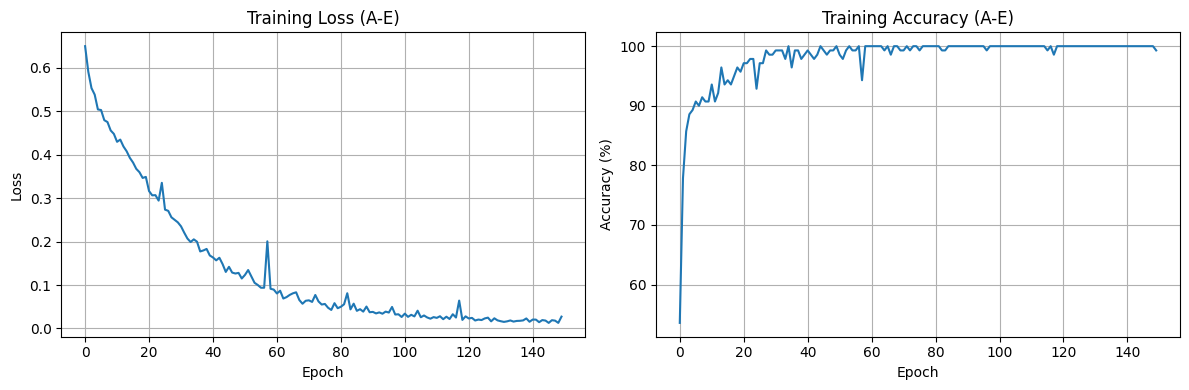

In [15]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss (A-E)')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accuracies)
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training Accuracy (A-E)')
plt.grid(True)

plt.tight_layout()
plt.show()

6. Evaluate and calculate accuracy

In [16]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for X_batch, y_batch in test_loader_AE:
        outputs = model(X_batch)
        predicted = (outputs > 0.5).float()
        correct += (predicted == y_batch).sum().item()
        total += y_batch.size(0)

accuracy = 100 * correct / total
print(f"Accuracy (A vs E): {accuracy:.2f}%") 

Accuracy (A vs E): 100.00%
